In [1]:
import os
os.chdir("c:/Users/pc/Documents/DentalTest")
print("Current working directory:", os.getcwd())

Current working directory: c:\Users\pc\Documents\DentalTest


<a href="https://colab.research.google.com/github/nitekar/DentalTest/blob/main/DentalTest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dental X-Ray Classification - ML Pipeline Demo

**Project**: End-to-End ML Pipeline for Dental Disease Classification
**Dataset**: Dental OPG X-Ray Images (6 classes)
**Model**: ResNet18 + Transfer Learning
**Performance**: 93%+ Accuracy

---

## 1. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import os

In [3]:
base_path = "data/Dental OPG (Classification)/"
categories = ["BDC-BDR", "Caries", "Fractured Teeth", "Healthy Teeth", "Impacted teeth", "Infection"]

In [4]:
image_paths = []
labels = []

for category in categories:
    category_path = os.path.join(base_path, category)
    for image_name in os.listdir(category_path):
        image_path = os.path.join(category_path, image_name)
        image_paths.append(image_path)
        labels.append(category)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

In [5]:
df.head()

,image_path,label
0,data/Dental OPG (Classification)/BDC-BDR\101.jpg,BDC-BDR
1,data/Dental OPG (Classification)/BDC-BDR\106.jpg,BDC-BDR
2,data/Dental OPG (Classification)/BDC-BDR\107.jpg,BDC-BDR
3,data/Dental OPG (Classification)/BDC-BDR\109.jpg,BDC-BDR
4,data/Dental OPG (Classification)/BDC-BDR\11.jpg,BDC-BDR


In [6]:
df.tail()

,image_path,label
512,data/Dental OPG (Classification)/Infection\77.jpg,Infection
513,data/Dental OPG (Classification)/Infection\8.jpg,Infection
514,data/Dental OPG (Classification)/Infection\84.jpg,Infection
515,data/Dental OPG (Classification)/Infection\85.jpg,Infection
516,data/Dental OPG (Classification)/Infection\87.jpg,Infection


In [7]:
df.shape

(517, 2)

In [8]:
df.columns

Index(['image_path', 'label'], dtype='object')

In [9]:
df.isnull().sum()

image_path    0
label         0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  517 non-null    object
 1   label       517 non-null    object
dtypes: object(2)
memory usage: 8.2+ KB


In [11]:
df['label'].unique()

array(['BDC-BDR', 'Caries', 'Fractured Teeth', 'Healthy Teeth',
       'Impacted teeth', 'Infection'], dtype=object)

In [12]:
df['label'].value_counts()

label
Healthy Teeth      223
Caries             119
Impacted teeth      87
BDC-BDR             52
Infection           23
Fractured Teeth     13
Name: count, dtype: int64

## 2. Exploratory Data Analysis (EDA)

Analyzing class distribution and visualizing sample images from each category.

C:\Users\pc\AppData\Local\Temp\ipykernel_15072\906518071.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label", palette="viridis", ax=ax)


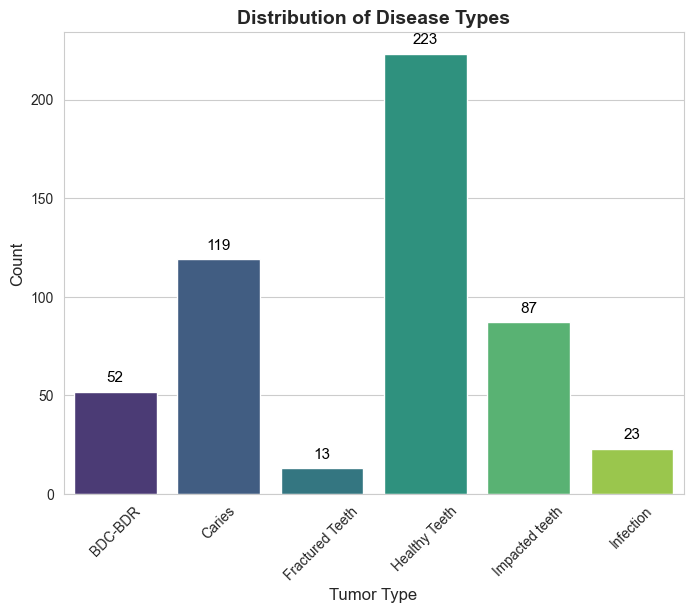

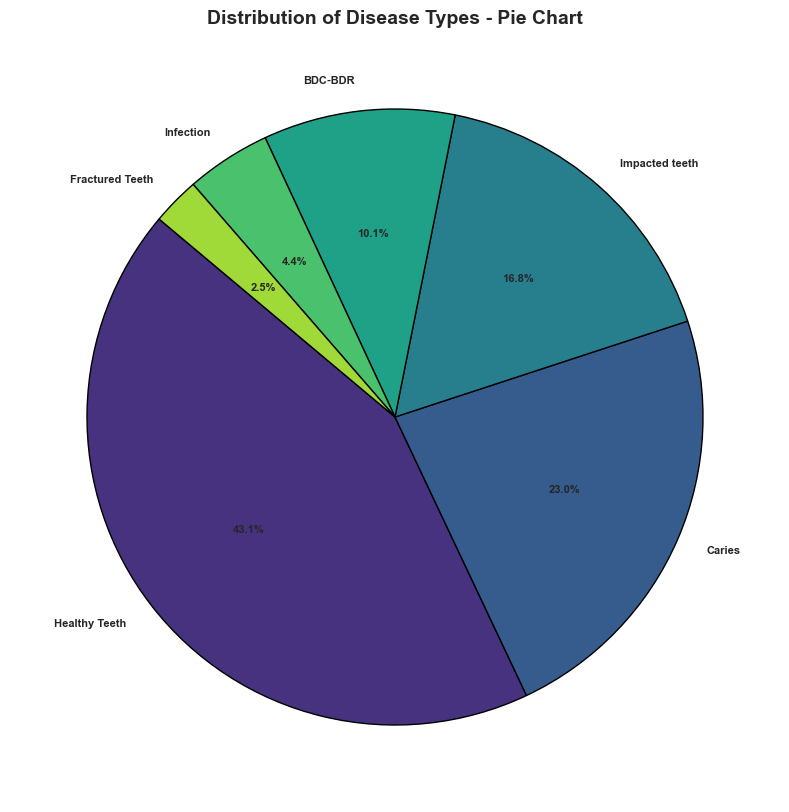

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(data=df, x="label", palette="viridis", ax=ax)

ax.set_title("Distribution of Disease Types", fontsize=14, fontweight='bold')
ax.set_xlabel("Tumor Type", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black',
                xytext=(0, 5), textcoords='offset points')

plt.xticks(rotation=45)
plt.show()

label_counts = df["label"].value_counts()

fig, ax = plt.subplots(figsize=(15, 10))
colors = sns.color_palette("viridis", len(label_counts))

ax.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',
       startangle=140, colors=colors, textprops={'fontsize': 8, 'weight': 'bold'},
       wedgeprops={'edgecolor': 'black', 'linewidth': 1})

ax.set_title("Distribution of Disease Types - Pie Chart", fontsize=14, fontweight='bold')

plt.show()

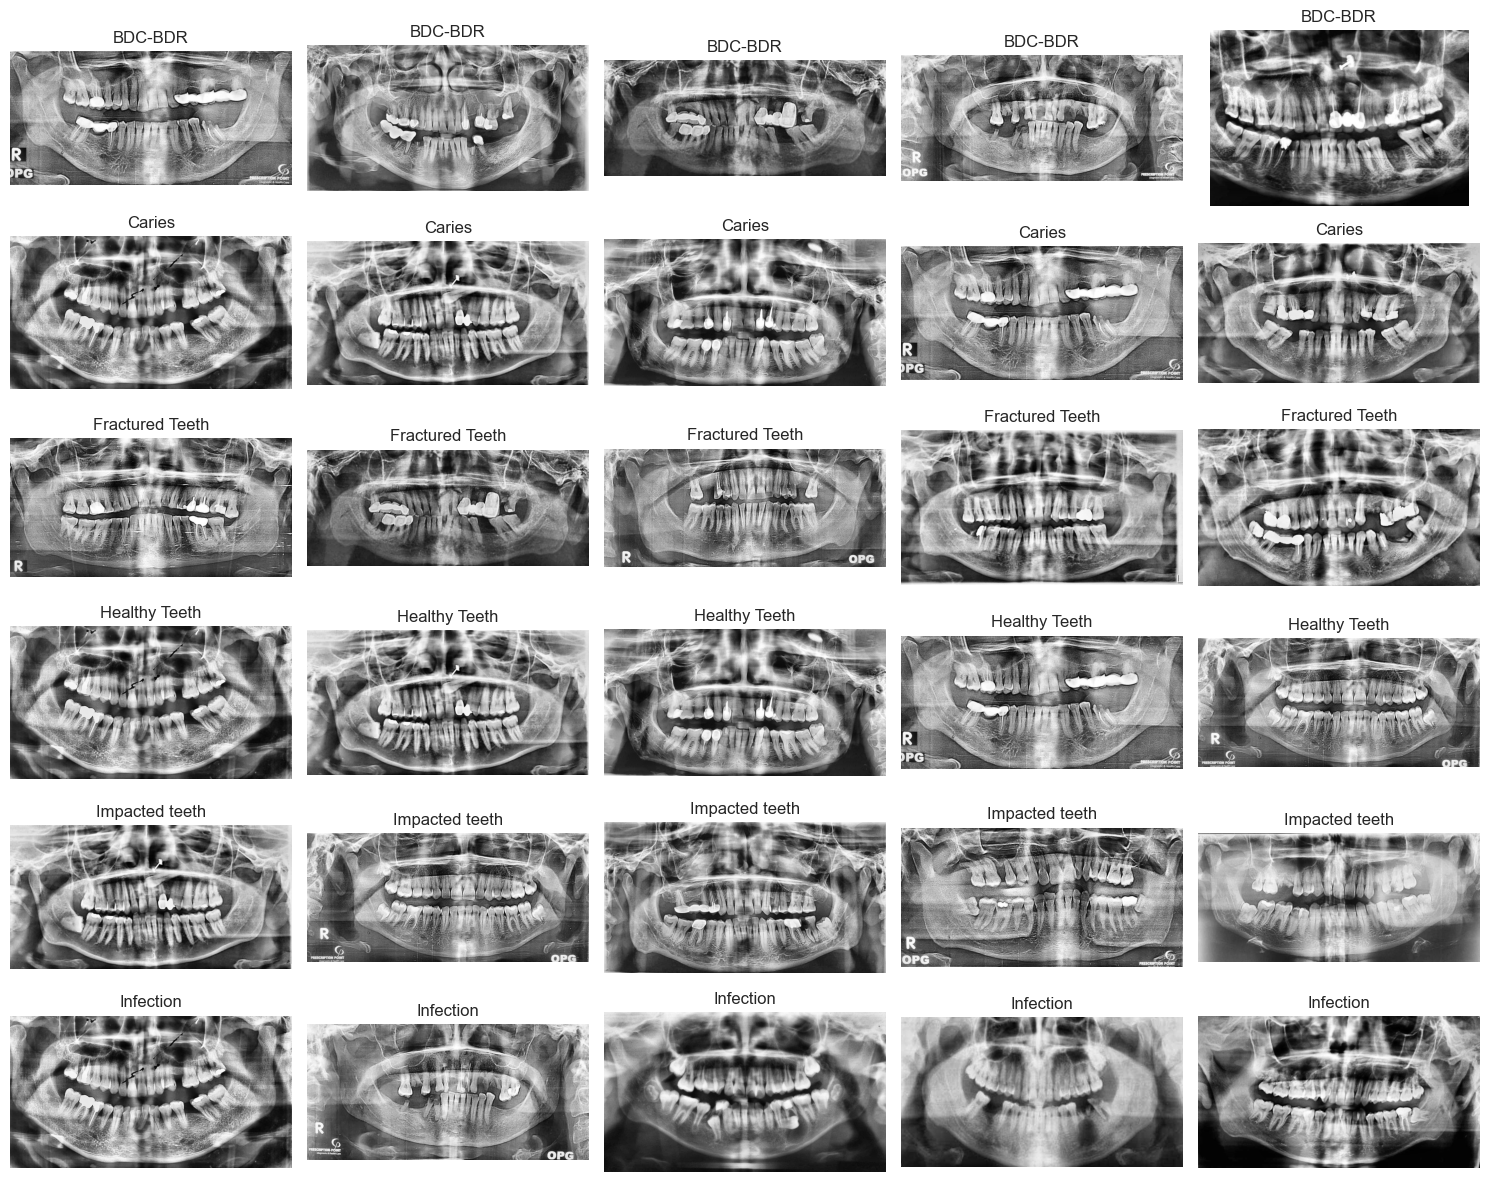

In [14]:
import cv2

num_images = 5

plt.figure(figsize=(15, 12))

for i, category in enumerate(categories):
    category_images = df[df['label'] == category]['image_path'].iloc[:num_images]

    for j, img_path in enumerate(category_images):

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(len(categories), num_images, i * num_images + j + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(category)

plt.tight_layout()
plt.show()

In [15]:
import warnings
warnings.filterwarnings('ignore')

## 3. Data Preprocessing & Balancing

Handling class imbalance using oversampling to ensure equal representation.

In [16]:
max_samples = df['label'].value_counts().max()

balanced_df = df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(n=max_samples, replace=True, random_state=42)
).reset_index(drop=True)

balanced_df = balanced_df[['image_path', 'label']]

In [17]:
df = balanced_df

In [18]:
df

,image_path,label
0,data/Dental OPG (Classification)/BDC-BDR\43.jpg,BDC-BDR
1,data/Dental OPG (Classification)/BDC-BDR\94.jpg,BDC-BDR
2,data/Dental OPG (Classification)/BDC-BDR\21.jpg,BDC-BDR
3,data/Dental OPG (Classification)/BDC-BDR\139.jpg,BDC-BDR
4,data/Dental OPG (Classification)/BDC-BDR\6.jpg,BDC-BDR
...,...,...
1333,data/Dental OPG (Classification)/Infection\85.jpg,Infection
1334,data/Dental OPG (Classification)/Infection\219...,Infection
1335,data/Dental OPG (Classification)/Infection\64.jpg,Infection
1336,data/Dental OPG (Classification)/Infection\64.jpg,Infection


## 4. Model Training & Evaluation

Training deep learning models with transfer learning and evaluating performance.

In [ ]:
import pandas as pd
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def preprocess_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    img = cv2.resize(img, (299, 299))
    img = img / 255.0
    return img

X = np.array([preprocess_image(path) for path in df['image_path']])
y = df['label'].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

X_train, X_temp, y_train, y_temp = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

base_model = InceptionResNetV2(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=20,
    verbose=1
)

for layer in base_model.layers[-50:]:
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=10,
    verbose=1
)

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

model.save('dental_classification_model.h5')


Epoch 1/20
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 424s 12s/step - accuracy: 0.2047 - loss: 2.3198 - val_accuracy: 0.2164 - val_loss: 1.7565
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 424s 12s/step - accuracy: 0.2047 - loss: 2.3198 - val_accuracy: 0.2164 - val_loss: 1.7565
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 415s 12s/step - accuracy: 0.2720 - loss: 1.7361 - val_accuracy: 0.2537 - val_loss: 1.7002
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 415s 12s/step - accuracy: 0.2720 - loss: 1.7361 - val_accuracy: 0.2537 - val_loss: 1.7002
Epoch 3/20
32/34 ━━━━━━━━━━━━━━━━━━━━ 23s 12s/step - accuracy: 0.3256 - loss: 1.6482

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, LayerNormalization, MultiHeadAttention, Dropout, Lambda
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

datagen = ImageDataGenerator(rescale=1./255)
train_gen = datagen.flow_from_dataframe(train_df, x_col='image_path', y_col='label', target_size=(299, 299), class_mode='categorical', batch_size=32, shuffle=True)
val_gen = datagen.flow_from_dataframe(val_df, x_col='image_path', y_col='label', target_size=(299, 299), class_mode='categorical', batch_size=32, shuffle=False)

input_tensor = Input(shape=(299, 299, 3))
base_model = InceptionResNetV2(include_top=False, weights='imagenet', input_tensor=input_tensor)
x = base_model.output
x = GlobalAveragePooling2D()(x)

attn_input = Lambda(lambda t: tf.expand_dims(t, axis=1))(x)
attn_output = MultiHeadAttention(num_heads=4, key_dim=64)(attn_input, attn_input)
attn_output = Lambda(lambda t: tf.squeeze(t, axis=1))(attn_output)

x = LayerNormalization()(x + attn_output)
x = Dropout(0.5)(x)
output = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_gen, validation_data=val_gen, epochs=10)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.tight_layout()
plt.show()

val_gen.reset()
pred = model.predict(val_gen)
y_pred = np.argmax(pred, axis=1)
y_true = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

NameError: name 'df' is not defined

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, LayerNormalization, MultiHeadAttention, Dropout, Lambda
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

datagen = ImageDataGenerator(rescale=1./255)
train_gen = datagen.flow_from_dataframe(train_df, x_col='image_path', y_col='label',
                                        target_size=(224, 224), class_mode='categorical', batch_size=32, shuffle=True)
val_gen = datagen.flow_from_dataframe(val_df, x_col='image_path', y_col='label',
                                      target_size=(224, 224), class_mode='categorical', batch_size=32, shuffle=False)

input_tensor = Input(shape=(224, 224, 3))
base_model = DenseNet121(include_top=False, weights='imagenet', input_tensor=input_tensor)
x = base_model.output
x = GlobalAveragePooling2D()(x)

attn_input = Lambda(lambda t: tf.expand_dims(t, axis=1))(x)
attn_output = MultiHeadAttention(num_heads=4, key_dim=64)(attn_input, attn_input)
attn_output = Lambda(lambda t: tf.squeeze(t, axis=1))(attn_output)

x = LayerNormalization()(x + attn_output)
x = Dropout(0.5)(x)
output = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_gen, validation_data=val_gen, epochs=10)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.tight_layout()
plt.show()

val_gen.reset()
pred = model.predict(val_gen)
y_pred = np.argmax(pred, axis=1)
y_true = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

NameError: name 'df' is not defined